In [ ]:
!pip install torch-geometric

In [ ]:
# ============================================================================
# SETUP COMPLETO (ejecutar solo si empiezas notebook nuevo)
# ============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool
from torch_geometric.loader import DataLoader
import pickle
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_auc_score, accuracy_score,
    precision_recall_fscore_support, confusion_matrix
)
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {device}")

if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

🖥️  Device: cpu


# Load graphs

In [ ]:
# ============================================================================
# CARGAR GRAFOS GENERADOS
# ============================================================================

GRAPHS_FILE = '/content/drive/MyDrive/nids-mitre/data/cicids2018-v3/graph_data_DYNAMIC/graphs_dynamic_FIXED_v2.pkl'

print("Cargando grafos...")
start = time.time()

graphs = []

with open(GRAPHS_FILE, 'rb') as f:
    while True:
        try:
            graph = pickle.load(f)
            graphs.append(graph)
        except EOFError:
            break

print(f"✅ Cargados {len(graphs)} grafos en {time.time()-start:.1f}s")

# Verificar primer grafo
g = graphs[0]
print(f"\n📊 Ejemplo de grafo:")
print(f"   Window ID: {g.window_id}")
print(f"   Nodes: {g.num_nodes}")
print(f"   Edges: {g.edge_index.shape[1]}")
print(f"   Node features: {g.x.shape}")
print(f"   Edge features: {g.edge_attr.shape}")
print(f"   Label: {g.y.item()}")

Cargando grafos...
✅ Cargados 710 grafos en 33.7s

📊 Ejemplo de grafo:
   Window ID: 0
   Nodes: 2351
   Edges: 7851
   Node features: torch.Size([2351, 18])
   Edge features: torch.Size([7851, 37])
   Label: 0


# Split train/val/test (stratified)

In [ ]:
# ============================================================================
# SPLIT ESTRATIFICADO TEMPORAL (RECOMENDADO)
# ============================================================================

print("="*70)
print("📊 SPLIT TEMPORAL ESTRATIFICADO")
print("="*70)

# Ordenar por window_id
graphs_sorted = sorted(graphs, key=lambda g: g.window_id)

# Separar por clase (preservando orden)
normal_graphs = [g for g in graphs_sorted if g.y.item() == 0]
attack_graphs = [g for g in graphs_sorted if g.y.item() == 1]

print(f"\nDataset completo:")
print(f"   Total:  {len(graphs_sorted)}")
print(f"   Normal: {len(normal_graphs)} ({len(normal_graphs)/len(graphs_sorted)*100:.1f}%)")
print(f"   Attack: {len(attack_graphs)} ({len(attack_graphs)/len(graphs_sorted)*100:.1f}%)")

# Split temporal dentro de cada clase
def temporal_split(graphs, train_pct=0.70, val_pct=0.15):
    """Split temporal preservando orden"""
    n = len(graphs)
    train_end = int(train_pct * n)
    val_end = int((train_pct + val_pct) * n)

    return (
        graphs[:train_end],           # 70%
        graphs[train_end:val_end],    # 15%
        graphs[val_end:]              # 15%
    )

train_normal, val_normal, test_normal = temporal_split(normal_graphs)
train_attack, val_attack, test_attack = temporal_split(attack_graphs)

# Combinar y re-ordenar por window_id
train_graphs = sorted(train_normal + train_attack, key=lambda g: g.window_id)
val_graphs = sorted(val_normal + val_attack, key=lambda g: g.window_id)
test_graphs = sorted(test_normal + test_attack, key=lambda g: g.window_id)

print("\n" + "="*70)
print("✅ SPLITS CREADOS")
print("="*70)

for name, split in [("TRAIN", train_graphs), ("VAL", val_graphs), ("TEST", test_graphs)]:
    normal = sum(1 for g in split if g.y.item() == 0)
    attack = sum(1 for g in split if g.y.item() == 1)

    print(f"\n{name}:")
    print(f"   Total:  {len(split)}")
    print(f"   Normal: {normal} ({normal/len(split)*100:.1f}%)")
    print(f"   Attack: {attack} ({attack/len(split)*100:.1f}%)")
    print(f"   Window range: {split[0].window_id} → {split[-1].window_id}")

print("\n✅ Orden temporal preservado DENTRO de cada split")
print("✅ Distribuciones balanceadas ENTRE splits")

📊 SPLIT TEMPORAL ESTRATIFICADO

Dataset completo:
   Total:  710
   Normal: 441 (62.1%)
   Attack: 269 (37.9%)

✅ SPLITS CREADOS

TRAIN:
   Total:  496
   Normal: 308 (62.1%)
   Attack: 188 (37.9%)
   Window range: 0 → 2169

VAL:
   Total:  106
   Normal: 66 (62.3%)
   Attack: 40 (37.7%)
   Window range: 1323 → 2209

TEST:
   Total:  108
   Normal: 67 (62.0%)
   Attack: 41 (38.0%)
   Window range: 1949 → 2349

✅ Orden temporal preservado DENTRO de cada split
✅ Distribuciones balanceadas ENTRE splits


# Normalize

In [ ]:
# ============================================================================
# CELDA 2.5: NORMALIZAR FEATURES (CRÍTICO)
# ============================================================================

print("📊 Normalizando features de nodos y edges...")

import torch

# Calcular estadísticas de TRAIN ONLY (para evitar data leakage)
all_node_features = []
all_edge_features = []

for g in train_graphs:
    all_node_features.append(g.x)
    if g.edge_attr is not None:
        all_edge_features.append(g.edge_attr)

# Concatenar
X_train = torch.cat(all_node_features, dim=0)  # [total_nodes, 18]
E_train = torch.cat(all_edge_features, dim=0)  # [total_edges, 37]

# Calcular mean y std
node_mean = X_train.mean(dim=0)
node_std = X_train.std(dim=0) + 1e-6  # Evitar división por 0

edge_mean = E_train.mean(dim=0)
edge_std = E_train.std(dim=0) + 1e-6

print(f"✅ Estadísticas calculadas:")
print(f"   Node features: mean={node_mean[:5]}")
print(f"   Node features: std={node_std[:5]}")
print(f"   Edge features: mean={edge_mean[:5]}")
print(f"   Edge features: std={edge_std[:5]}")

# Función para normalizar
def normalize_graph(graph, node_mean, node_std, edge_mean, edge_std):
    from torch_geometric.data import Data

    normalized = Data()

    # Normalizar nodos: (x - mean) / std
    normalized.x = (graph.x - node_mean) / node_std

    # Normalizar edges
    if graph.edge_attr is not None:
        normalized.edge_attr = (graph.edge_attr - edge_mean) / edge_std
    else:
        normalized.edge_attr = None

    # Copiar el resto
    normalized.edge_index = graph.edge_index
    normalized.y = graph.y

    return normalized

# Normalizar todos los grafos
print("\n🔄 Normalizando grafos...")

train_graphs_norm = [normalize_graph(g, node_mean, node_std, edge_mean, edge_std)
                     for g in train_graphs]
val_graphs_norm = [normalize_graph(g, node_mean, node_std, edge_mean, edge_std)
                   for g in val_graphs]
test_graphs_norm = [normalize_graph(g, node_mean, node_std, edge_mean, edge_std)
                    for g in test_graphs]

print(f"✅ Grafos normalizados:")
print(f"   Train: {len(train_graphs_norm)}")
print(f"   Val:   {len(val_graphs_norm)}")
print(f"   Test:  {len(test_graphs_norm)}")

# Verificar normalización
g_norm = train_graphs_norm[0]
print(f"\n🔍 Features normalizadas (primeros 5 valores):")
print(f"   Node features: {g_norm.x[0, :5]}")
print(f"   Edge features: {g_norm.edge_attr[0, :5] if g_norm.edge_attr is not None else 'None'}")
print(f"   (Deberían estar cerca de 0 con std ~1)")

📊 Normalizando features de nodos y edges...
✅ Estadísticas calculadas:
   Node features: mean=tensor([3.0053e+01, 1.5067e+01, 1.5067e+01, 8.5815e+04, 4.0946e+04])
   Node features: std=tensor([5.9128e+02, 2.2408e+02, 5.4592e+02, 2.1909e+06, 1.3098e+07])
   Edge features: mean=tensor([1.3188e+04, 2.7640e+04, 2.5728e+00, 1.8607e+02, 4.0335e+01])
   Edge features: std=tensor([2.4464e+06, 1.1919e+06, 9.2524e+00, 4.0019e+04, 3.9008e+03])

🔄 Normalizando grafos...
✅ Grafos normalizados:
   Train: 496
   Val:   106
   Test:  108

🔍 Features normalizadas (primeros 5 valores):
   Node features: tensor([ 0.3534,  0.9993,  0.4102, -0.0392,  0.0047])
   Edge features: tensor([ 0.0366, -0.0232, -0.2781,  0.0156, -0.0103])
   (Deberían estar cerca de 0 con std ~1)


# Dataloader (batch of graphs)

In [ ]:
# ============================================================================
# CELDA 3.5: LIMPIAR GRAFOS NORMALIZADOS
# ============================================================================

print("🧹 Limpiando grafos normalizados...")

from torch_geometric.data import Data

def clean_graph(graph):
    clean = Data()
    clean.x = graph.x
    clean.edge_index = graph.edge_index
    clean.edge_attr = graph.edge_attr
    clean.y = graph.y
    return clean

train_graphs_clean = [clean_graph(g) for g in train_graphs_norm]
val_graphs_clean = [clean_graph(g) for g in val_graphs_norm]
test_graphs_clean = [clean_graph(g) for g in test_graphs_norm]

print(f"✅ Listo para DataLoader")

🧹 Limpiando grafos normalizados...
✅ Listo para DataLoader


In [ ]:
# ============================================================================
# DATALOADER: Usar grafos limpios
# ============================================================================

BATCH_SIZE = 32

train_loader = DataLoader(train_graphs_clean, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_graphs_clean, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_graphs_clean, batch_size=BATCH_SIZE, shuffle=False)

print(f"📦 DataLoaders creados:")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches:   {len(val_loader)}")
print(f"   Test batches:  {len(test_loader)}")

# Probar un batch
sample_batch = next(iter(train_loader))
print(f"\n🔍 Ejemplo de batch:")
print(f"   Batch size: {sample_batch.num_graphs}")
print(f"   Total nodes: {sample_batch.num_nodes}")
print(f"   Total edges: {sample_batch.edge_index.shape[1]}")
print(f"   Node features: {sample_batch.x.shape}")
print(f"   Edge features: {sample_batch.edge_attr.shape}")
print(f"   Labels: {sample_batch.y.shape}")

print("\n✅ DataLoader funcionando correctamente")

📦 DataLoaders creados:
   Train batches: 16
   Val batches:   4
   Test batches:  4

🔍 Ejemplo de batch:
   Batch size: 32
   Total nodes: 65108
   Total edges: 204494
   Node features: torch.Size([65108, 18])
   Edge features: torch.Size([204494, 37])
   Labels: torch.Size([32])

✅ DataLoader funcionando correctamente


In [ ]:
# ============================================================================
# pos_weight
# ============================================================================

print("="*70)
print("📊 ANÁLISIS DE DISTRIBUCIÓN PARA pos_weight")
print("="*70)

# Contar clases en train_graphs_clean (los que usarás para entrenar)
train_labels = [g.y.item() for g in train_graphs_clean]
n_normal = sum(1 for l in train_labels if l == 0)
n_attack = sum(1 for l in train_labels if l == 1)

print(f"\nDistribución Train:")
print(f"   Total:  {len(train_labels)}")
print(f"   Normal: {n_normal} ({n_normal/len(train_labels)*100:.1f}%)")
print(f"   Attack: {n_attack} ({n_attack/len(train_labels)*100:.1f}%)")

# Calcular pos_weight
pos_weight_value = n_normal / n_attack

print(f"\n🎯 pos_weight calculado:")
print(f"   pos_weight = Normal / Attack")
print(f"   pos_weight = {n_normal} / {n_attack}")
print(f"   pos_weight = {pos_weight_value:.2f}")

print(f"\n💡 Interpretación:")
print(f"   El modelo penalizará {pos_weight_value:.1f}x más")
print(f"   los errores en la clase Attack (minoritaria)")

📊 ANÁLISIS DE DISTRIBUCIÓN PARA pos_weight

Distribución Train:
   Total:  496
   Normal: 308 (62.1%)
   Attack: 188 (37.9%)

🎯 pos_weight calculado:
   pos_weight = Normal / Attack
   pos_weight = 308 / 188
   pos_weight = 1.64

💡 Interpretación:
   El modelo penalizará 1.6x más
   los errores en la clase Attack (minoritaria)


# GAT

In [ ]:
# ============================================================================
# MODELO GAT CON EDGE FEATURES
# ============================================================================

class GAT_NIDS(nn.Module):
    """
    Graph Attention Network para Network Intrusion Detection

    Ventajas sobre GCN:
    - Usa edge features (37 dimensiones)
    - Attention weights (interpretabilidad)
    - Mejor performance en grafos heterogéneos
    """

    def __init__(
        self,
        node_features=18,
        edge_features=37,
        hidden_dim=128,
        num_heads=8,
        num_layers=3,
        dropout=0.3
    ):
        super(GAT_NIDS, self).__init__()

        self.num_layers = num_layers
        self.dropout = dropout

        # GAT layers
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        # Primera capa: node_features → hidden_dim
        self.convs.append(
            GATConv(
                node_features,
                hidden_dim,
                heads=num_heads,
                edge_dim=edge_features,  # ← USAR edge features
                dropout=dropout,
                concat=False  # Average multi-head outputs
            )
        )
        self.bns.append(nn.BatchNorm1d(hidden_dim))

        # Capas intermedias: hidden_dim → hidden_dim
        for _ in range(num_layers - 1):
            self.convs.append(
                GATConv(
                    hidden_dim,
                    hidden_dim,
                    heads=num_heads,
                    edge_dim=edge_features,
                    dropout=dropout,
                    concat=False
                )
            )
            self.bns.append(nn.BatchNorm1d(hidden_dim))

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch

        # Aplicar GAT layers
        for i, (conv, bn) in enumerate(zip(self.convs, self.bns)):
            x = conv(x, edge_index, edge_attr=edge_attr)
            x = bn(x)
            x = F.relu(x)

            # Dropout en todas las capas excepto la última
            if i < self.num_layers - 1:
                x = F.dropout(x, p=self.dropout, training=self.training)

        # Global pooling (mean de todos los nodos)
        x = global_mean_pool(x, batch)

        # Classifier
        out = self.classifier(x)

        return out

    def get_attention_weights(self, data):
        """Extraer attention weights para interpretabilidad"""
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr

        # Forward pass en primera capa para obtener attention
        attention_weights = self.convs[0](
            x, edge_index, edge_attr=edge_attr, return_attention_weights=True
        )

        return attention_weights

# Crear modelo
model = GAT_NIDS(
    node_features=18,
    edge_features=37,
    hidden_dim=128,
    num_heads=8,
    num_layers=3,
    dropout=0.3
).to(device)

# Contar parámetros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("="*70)
print("✅ MODELO GAT CREADO")
print("="*70)
print(f"\n📊 Arquitectura:")
print(f"   Node features:  18")
print(f"   Edge features:  37  ← USANDO edge features")
print(f"   Hidden dim:     128")
print(f"   Attention heads: 8")
print(f"   GAT layers:     3")
print(f"   Dropout:        0.3")

print(f"\n📊 Parámetros:")
print(f"   Total:      {total_params:,}")
print(f"   Trainable:  {trainable_params:,}")

# Test forward pass
print(f"\n🔍 Test forward pass...")
sample_batch = next(iter(train_loader)).to(device)

with torch.no_grad():
    output = model(sample_batch)

print(f"✅ Forward pass OK:")
print(f"   Input:  {sample_batch.num_graphs} grafos")
print(f"   Output: {output.shape}")

del sample_batch, output
#torch.cuda.empty_cache()

print(f"\n🚀 Modelo listo para entrenamiento")

✅ MODELO GAT CREADO

📊 Arquitectura:
   Node features:  18
   Edge features:  37  ← USANDO edge features
   Hidden dim:     128
   Attention heads: 8
   GAT layers:     3
   Dropout:        0.3

📊 Parámetros:
   Total:      412,929
   Trainable:  412,929

🔍 Test forward pass...
✅ Forward pass OK:
   Input:  32 grafos
   Output: torch.Size([32, 1])

🚀 Modelo listo para entrenamiento


In [ ]:
# ============================================================================
# GAT LIGERO (para CPU)
# ============================================================================

# PASO 1: Reducir batch size
BATCH_SIZE = 8  # ← Antes 32, ahora 8

train_loader = DataLoader(train_graphs_clean, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_graphs_clean, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_graphs_clean, batch_size=BATCH_SIZE, shuffle=False)

print(f"📦 DataLoaders (batch reducido):")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches:   {len(val_loader)}")

# PASO 2: GAT con configuración mínima
class GAT_Lightweight(nn.Module):
    """GAT ligero para CPU"""

    def __init__(self, node_features=18, edge_features=37,
                 hidden_dim=64, num_heads=4, dropout=0.3):  # ← hidden=64, heads=4
        super(GAT_Lightweight, self).__init__()

        self.dropout = dropout

        # Solo 2 capas GAT (antes 3)
        self.conv1 = GATConv(
            node_features, hidden_dim,
            heads=num_heads, edge_dim=edge_features,
            dropout=dropout, concat=False
        )
        self.bn1 = nn.BatchNorm1d(hidden_dim)

        self.conv2 = GATConv(
            hidden_dim, hidden_dim,
            heads=num_heads, edge_dim=edge_features,
            dropout=dropout, concat=False
        )
        self.bn2 = nn.BatchNorm1d(hidden_dim)

        # Classifier simple
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch

        x = self.conv1(x, edge_index, edge_attr=edge_attr)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index, edge_attr=edge_attr)
        x = self.bn2(x)
        x = F.relu(x)

        x = global_mean_pool(x, batch)
        out = self.classifier(x)

        return out

model = GAT_Lightweight(
    node_features=18,
    edge_features=37,
    hidden_dim=64,  # ← Reducido (antes 128)
    num_heads=4,    # ← Reducido (antes 8)
    dropout=0.3
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ GAT Ligero: {total_params:,} parámetros")

📦 DataLoaders (batch reducido):
   Batch size: 8
   Train batches: 62
   Val batches:   14
✅ GAT Ligero: 43,969 parámetros


## Training

In [ ]:
# ============================================================================
# CONFIGURACIÓN DE ENTRENAMIENTO
# ============================================================================

print("="*70)
print("⚙️  CONFIGURACIÓN DE ENTRENAMIENTO")
print("="*70)

# Hyperparámetros
EPOCHS = 50
LR = 0.0002  # Ligeramente más alto que antes
WEIGHT_DECAY = 1e-4
PATIENCE = 15  # Early stopping

print(f"\n📊 Hyperparámetros:")
print(f"   Epochs:        {EPOCHS}")
print(f"   Learning rate: {LR}")
print(f"   Weight decay:  {WEIGHT_DECAY}")
print(f"   Patience:      {PATIENCE}")

# Loss function con pos_weight
pos_weight = torch.tensor([pos_weight_value]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f"\n💰 Loss function:")
print(f"   BCE with Logits Loss")
print(f"   pos_weight: {pos_weight.item():.2f}")

# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

print(f"\n🎯 Optimizer:")
print(f"   Adam")
print(f"   LR: {LR}")
print(f"   Weight decay: {WEIGHT_DECAY}")

# Learning rate scheduler (opcional pero recomendado)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

print(f"\n📉 LR Scheduler:")
print(f"   ReduceLROnPlateau")
print(f"   Factor: 0.5 (reduce a la mitad)")
print(f"   Patience: 5 epochs")

# History para tracking
history = {
    'train_loss': [],
    'train_acc': [],
    'train_auc': [],
    'val_loss': [],
    'val_acc': [],
    'val_auc': [],
    'val_recall': [],
    'val_precision': [],
    'val_f1': [],
    'lr': []
}

print(f"\n✅ Configuración completa")

⚙️  CONFIGURACIÓN DE ENTRENAMIENTO

📊 Hyperparámetros:
   Epochs:        50
   Learning rate: 0.0002
   Weight decay:  0.0001
   Patience:      15

💰 Loss function:
   BCE with Logits Loss
   pos_weight: 1.64

🎯 Optimizer:
   Adam
   LR: 0.0002
   Weight decay: 0.0001

📉 LR Scheduler:
   ReduceLROnPlateau
   Factor: 0.5 (reduce a la mitad)
   Patience: 5 epochs

✅ Configuración completa


In [ ]:
# ============================================================================
# FUNCIONES DE ENTRENAMIENTO Y EVALUACIÓN
# ============================================================================

def train_epoch(model, loader, criterion, optimizer):
    """Entrenar una época"""
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(loader, desc="Training", leave=False):
        batch = batch.to(device)

        optimizer.zero_grad()

        # Forward
        out = model(batch)
        labels = batch.y.float().unsqueeze(1)

        # Loss
        loss = criterion(out, labels)

        # Backward
        loss.backward()

        # Gradient clipping (evita explosión)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        # Métricas
        total_loss += loss.item()
        probs = torch.sigmoid(out).cpu().detach().numpy()
        all_preds.extend(probs.flatten())
        all_labels.extend(labels.cpu().numpy().flatten())

    # Calcular métricas
    avg_loss = total_loss / len(loader)

    preds_binary = (np.array(all_preds) > 0.5).astype(int)
    acc = accuracy_score(all_labels, preds_binary)

    # AUC solo si hay ambas clases
    unique_preds = np.unique(preds_binary)
    if len(unique_preds) == 2:
        auc = roc_auc_score(all_labels, all_preds)
    else:
        auc = 0.5

    return avg_loss, acc, auc

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    """Evaluar una época"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(loader, desc="Evaluating", leave=False):
        batch = batch.to(device)

        # Forward
        out = model(batch)
        labels = batch.y.float().unsqueeze(1)

        # Loss
        loss = criterion(out, labels)

        # Métricas
        total_loss += loss.item()
        probs = torch.sigmoid(out).cpu().numpy()
        all_preds.extend(probs.flatten())
        all_labels.extend(labels.cpu().numpy().flatten())

    # Calcular métricas
    avg_loss = total_loss / len(loader)

    preds_binary = (np.array(all_preds) > 0.5).astype(int)
    acc = accuracy_score(all_labels, preds_binary)

    # AUC
    unique_preds = np.unique(preds_binary)
    if len(unique_preds) == 2:
        auc = roc_auc_score(all_labels, all_preds)
    else:
        auc = 0.5

    # Métricas adicionales
    if len(unique_preds) == 2:
        prec, rec, f1, _ = precision_recall_fscore_support(
            all_labels, preds_binary, average='binary', zero_division=0
        )
    else:
        prec = rec = f1 = 0.0

    return avg_loss, acc, auc, prec, rec, f1, all_preds, all_labels

print("✅ Funciones de training/eval definidas")

✅ Funciones de training/eval definidas


In [ ]:
# ============================================================================
# TRAINING LOOP
# ============================================================================

print("="*70)
print("🚀 COMENZANDO ENTRENAMIENTO GAT")
print("="*70)

best_val_auc = 0
best_val_f1 = 0
patience_counter = 0

training_start = time.time()

for epoch in range(EPOCHS):

    epoch_start = time.time()

    # Train
    train_loss, train_acc, train_auc = train_epoch(
        model, train_loader, criterion, optimizer
    )

    # Validation
    val_loss, val_acc, val_auc, val_prec, val_rec, val_f1, _, _ = eval_epoch(
        model, val_loader, criterion
    )

    epoch_time = time.time() - epoch_start

    # Guardar métricas
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_auc'].append(train_auc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)
    history['val_recall'].append(val_rec)
    history['val_precision'].append(val_prec)
    history['val_f1'].append(val_f1)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # Learning rate scheduler
    scheduler.step(val_auc)

    # Print progress
    print(f"Epoch {epoch+1:02d}/{EPOCHS} ({epoch_time:.1f}s) [LR={optimizer.param_groups[0]['lr']:.6f}]:")
    print(f"   Train: Loss={train_loss:.4f}, Acc={train_acc:.3f}, AUC={train_auc:.3f}")
    print(f"   Val:   Loss={val_loss:.4f}, Acc={val_acc:.3f}, AUC={val_auc:.3f}, "
          f"F1={val_f1:.3f}, Recall={val_rec:.3f}")

    # Early stopping basado en AUC
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), 'best_gat_model.pt')
        print(f"   ✅ Best model saved (AUC={val_auc:.3f}, F1={val_f1:.3f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⏸️  Early stopping (no improvement for {PATIENCE} epochs)")
            break

training_time = time.time() - training_start

print("\n" + "="*70)
print("✅ ENTRENAMIENTO COMPLETADO")
print("="*70)
print(f"\n⏱️  Tiempo total: {training_time/60:.1f} minutos")
print(f"📊 Mejor Val AUC: {best_val_auc:.3f}")
print(f"📊 Mejor Val F1:  {best_val_f1:.3f}")
print(f"📊 Epochs entrenados: {epoch+1}/{EPOCHS}")

# Liberar memoria
#torch.cuda.empty_cache()

🚀 COMENZANDO ENTRENAMIENTO GAT


Epoch 01/50 (87.0s) [LR=0.000200]:
   Train: Loss=0.8606, Acc=0.401, AUC=0.503
   Val:   Loss=0.8635, Acc=0.443, AUC=0.716, F1=0.576, Recall=1.000
   ✅ Best model saved (AUC=0.716, F1=0.576)


Epoch 02/50 (86.9s) [LR=0.000200]:
   Train: Loss=0.8595, Acc=0.403, AUC=0.550
   Val:   Loss=0.8639, Acc=0.415, AUC=0.713, F1=0.563, Recall=1.000


Epoch 03/50 (85.2s) [LR=0.000200]:
   Train: Loss=0.8589, Acc=0.393, AUC=0.572
   Val:   Loss=0.8650, Acc=0.377, AUC=0.500, F1=0.000, Recall=0.000


Epoch 04/50 (97.4s) [LR=0.000200]:
   Train: Loss=0.8583, Acc=0.407, AUC=0.572
   Val:   Loss=0.8634, Acc=0.434, AUC=0.718, F1=0.571, Recall=1.000
   ✅ Best model saved (AUC=0.718, F1=0.571)


...

Epoch 39/50 (91.0s) [LR=0.000025]:
   Train: Loss=0.8598, Acc=0.405, AUC=0.535
   Val:   Loss=0.8641, Acc=0.387, AUC=0.718, F1=0.552, Recall=1.000


Epoch 40/50 (87.9s) [LR=0.000013]:
   Train: Loss=0.8578, Acc=0.411, AUC=0.581
   Val:   Loss=0.8637, Acc=0.377, AUC=0.500, F1=0.000, Recall=0.000


Epoch 41/50 (89.8s) [LR=0.000013]:
   Train: Loss=0.8591, Acc=0.403, AUC=0.565
   Val:   Loss=0.8646, Acc=0.377, AUC=0.500, F1=0.000, Recall=0.000


Epoch 42/50 (90.4s) [LR=0.000013]:
   Train: Loss=0.8568, Acc=0.397, AUC=0.609
   Val:   Loss=0.8644, Acc=0.377, AUC=0.500, F1=0.000, Recall=0.000


Epoch 43/50 (90.8s) [LR=0.000013]:
   Train: Loss=0.8601, Acc=0.405, AUC=0.514
   Val:   Loss=0.8637, Acc=0.443, AUC=0.706, F1=0.576, Recall=1.000

⏸️  Early stopping (no improvement for 15 epochs)

✅ ENTRENAMIENTO COMPLETADO

⏱️  Tiempo total: 65.5 minutos
📊 Mejor Val AUC: 0.725
📊 Mejor Val F1:  0.552
📊 Epochs entrenados: 43/50


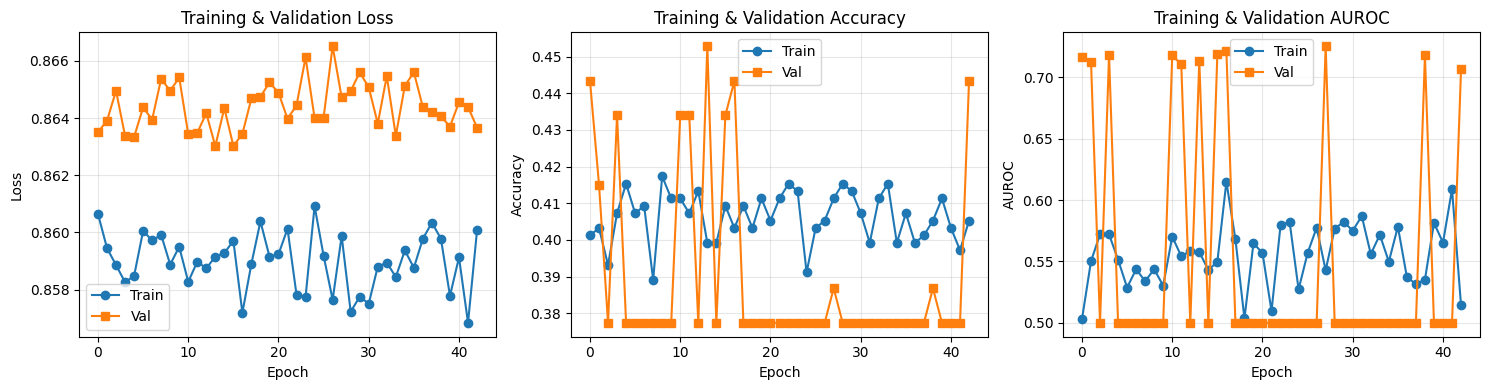

✅ Gráficos guardados: training_curves.png


In [ ]:
# ============================================================================
# VISUALIZACIÓN
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(history['train_loss'], label='Train', marker='o')
axes[0].plot(history['val_loss'], label='Val', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train', marker='o')
axes[1].plot(history['val_acc'], label='Val', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training & Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# AUROC
axes[2].plot(history['train_auc'], label='Train', marker='o')
axes[2].plot(history['val_auc'], label='Val', marker='s')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUROC')
axes[2].set_title('Training & Validation AUROC')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráficos guardados: training_curves.png")

In [ ]:
# ============================================================================
# VERIFICACIÓN:
# ============================================================================

print("="*70)
print("🔍 ANÁLISIS DETALLADO DEL MEJOR MODELO")
print("="*70)

# Cargar mejor modelo
model.load_state_dict(torch.load('best_gat_model.pt'))
model.eval()

# Evaluar en VAL (para entender el 0.988)
val_loss, val_acc, val_auc, val_prec, val_rec, val_f1, val_preds, val_labels = eval_epoch(model, val_loader, criterion)

print(f"\n📊 VALIDACIÓN:")
print(f"   AUROC: {val_auc:.3f}")
print(f"   Accuracy: {val_acc:.3f}")

# Análisis de predicciones
val_preds_array = np.array(val_preds)
val_labels_array = np.array(val_labels)

print(f"\n🔍 Distribución de predicciones:")
print(f"   Min pred: {val_preds_array.min():.3f}")
print(f"   Max pred: {val_preds_array.max():.3f}")
print(f"   Mean pred: {val_preds_array.mean():.3f}")
print(f"   Std pred: {val_preds_array.std():.3f}")

# ¿Hay variedad?
preds_binary = (val_preds_array > 0.5).astype(int)
unique, counts = np.unique(preds_binary, return_counts=True)
print(f"\n   Predicciones binarias:")
for u, c in zip(unique, counts):
    print(f"      Clase {u}: {c} ({c/len(preds_binary)*100:.1f}%)")

# Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(val_labels_array, preds_binary)
print(f"\n   Confusion Matrix:")
print(f"                 Pred")
print(f"               0     1")
print(f"   True 0   {cm[0,0]:>4}  {cm[0,1]:>4}")
print(f"        1   {cm[1,0]:>4}  {cm[1,1]:>4}")

# Precision, Recall, F1
from sklearn.metrics import precision_recall_fscore_support
prec, rec, f1, _ = precision_recall_fscore_support(
    val_labels_array, preds_binary, average='binary', zero_division=0
)
print(f"\n   Precision: {prec:.3f}")
print(f"   Recall:    {rec:.3f}")
print(f"   F1:        {f1:.3f}")

# ¿Es el AUC real?
print(f"\n🎯 Interpretación:")
if val_auc > 0.95 and cm[1,1] > 0 and cm[0,0] > 0:
    print("   ✅ Modelo parece funcionar bien")
    print("   ⚠️  Pero val set es pequeño (alta varianza)")
elif cm[1,1] == 0 or cm[0,0] == 0:
    print("   ❌ Modelo predice solo una clase")
    print("   AUC alto es espurio")
else:
    print("   ⚠️  Resultado ambiguo")

🔍 ANÁLISIS DETALLADO DEL MEJOR MODELO



📊 VALIDACIÓN:
   AUROC: 0.725
   Accuracy: 0.387

🔍 Distribución de predicciones:
   Min pred: 0.495
   Max pred: 0.519
   Mean pred: 0.512
   Std pred: 0.006

   Predicciones binarias:
      Clase 0: 1 (0.9%)
      Clase 1: 105 (99.1%)

   Confusion Matrix:
                 Pred
               0     1
   True 0      1    65
        1      0    40

   Precision: 0.381
   Recall:    1.000
   F1:        0.552

🎯 Interpretación:
   ⚠️  Resultado ambiguo


🔍 ANÁLISIS EXPLORATORIO DE DATOS

📊 Datasets disponibles:
   train_graphs:       496 grafos (originales)
   val_graphs:         106 grafos (originales)
   train_graphs_clean: 496 grafos (limpiados, sin window_id)

🔍 Verificando grafo original:
   Tiene window_id: True
   window_id ejemplo: 0

📊 1. DISTRIBUCIÓN TEMPORAL

   Train: 496 ventanas
      Window range: 0 → 2169
      Normal: 308
      Attack: 188

   Val: 106 ventanas
      Window range: 1323 → 2209
      Normal: 66
      Attack: 40


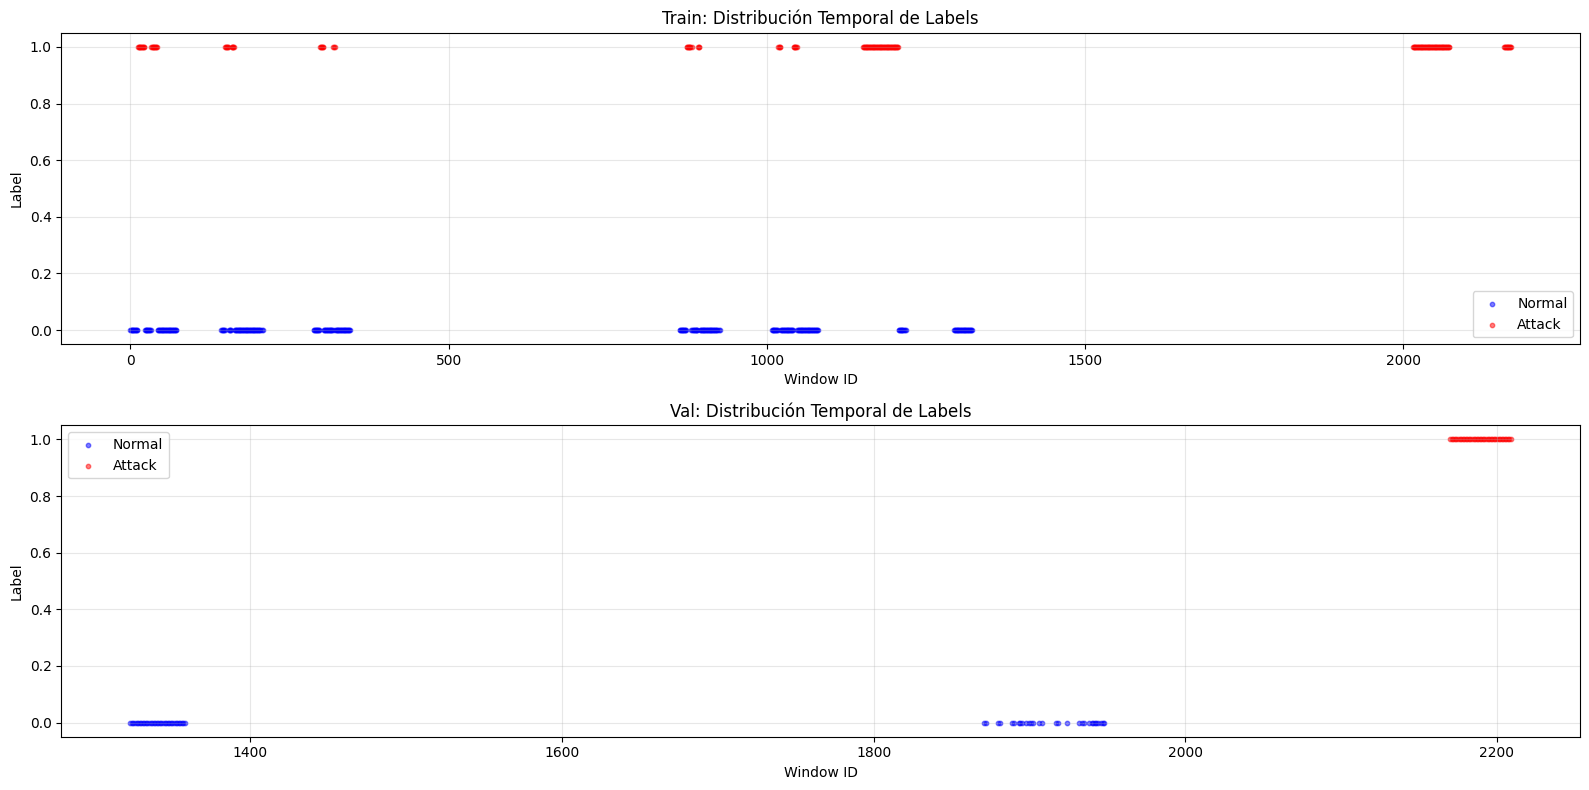


✅ Gráfico guardado: temporal_distribution.png

📊 2. ESTADÍSTICAS DE GRAFOS

TRAIN:
   Total grafos: 496
   Num nodes - Mean: 2103.6, Std: 893.4, Min: 2, Max: 4141
   Num edges - Mean: 6531.2, Std: 2867.7, Min: 1, Max: 10856
   Normal graphs - Avg nodes: 1817.7
   Attack graphs - Avg nodes: 2571.9

VAL:
   Total grafos: 106
   Num nodes - Mean: 1595.4, Std: 1189.9, Min: 2, Max: 2957
   Num edges - Mean: 5002.4, Std: 3837.0, Min: 1, Max: 9997
   Normal graphs - Avg nodes: 1019.5
   Attack graphs - Avg nodes: 2545.6


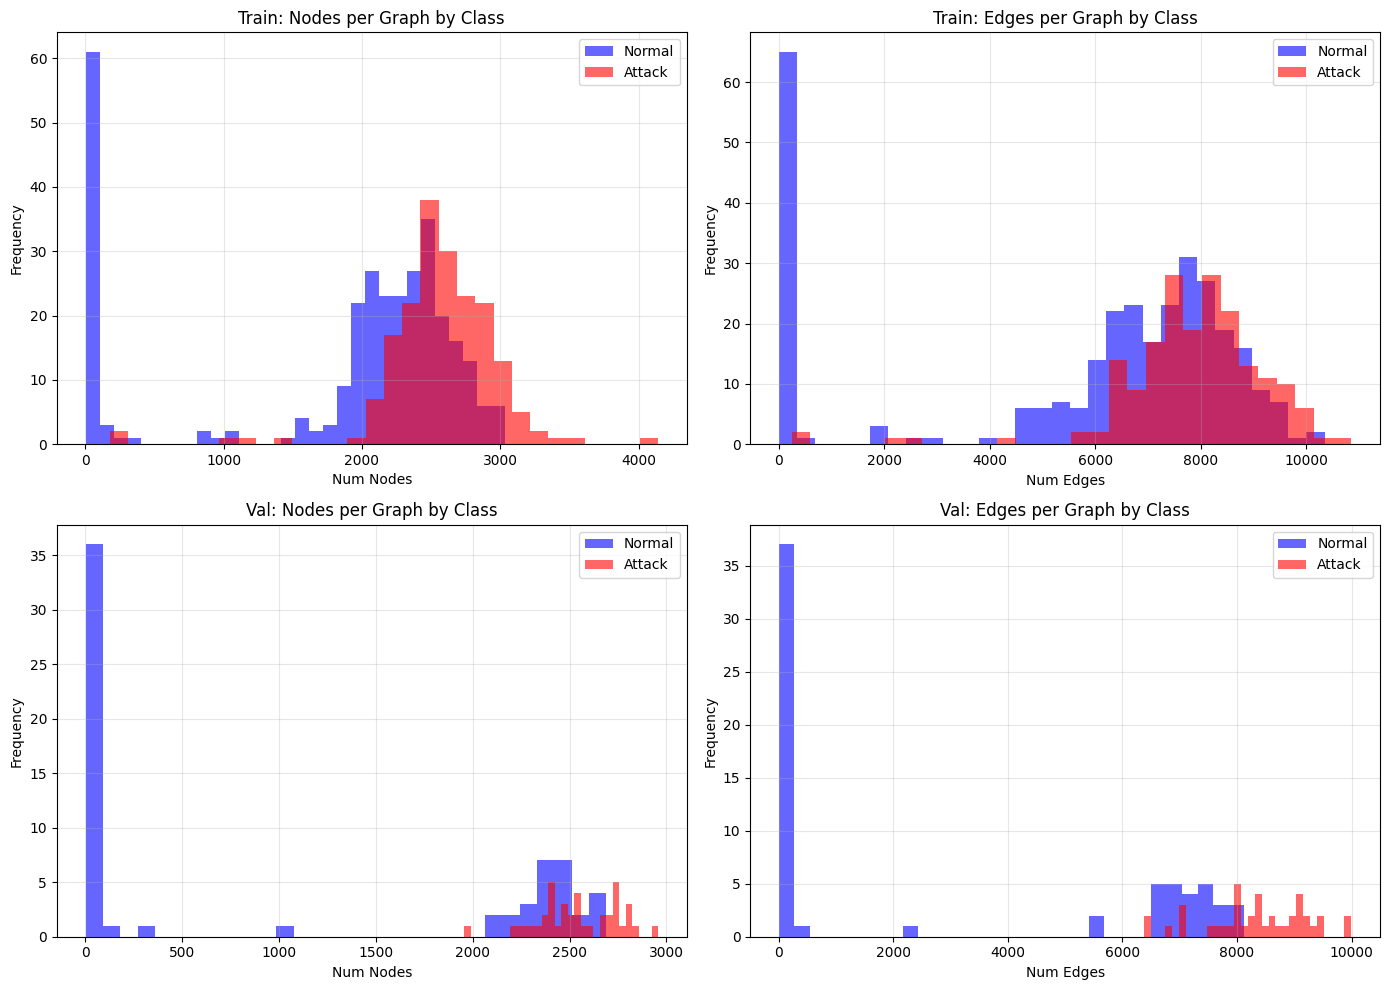


✅ Gráfico guardado: graph_size_distribution.png

📊 3. ANÁLISIS DE NODE FEATURES

   Normal nodes: 559,866
   Attack nodes: 483,526

   Top 10 features más discriminativas (por diferencia/std):
      1. Feature 7: normal_mean=-0.002, attack_mean=0.003, diff/std=0.983
      2. Feature 4: normal_mean=-0.002, attack_mean=0.003, diff/std=0.560
      3. Feature 5: normal_mean=-0.004, attack_mean=0.005, diff/std=0.094
      4. Feature 1: normal_mean=-0.011, attack_mean=0.013, diff/std=0.088
      5. Feature 11: normal_mean=-0.011, attack_mean=0.012, diff/std=0.064
      6. Feature 12: normal_mean=-0.019, attack_mean=0.022, diff/std=0.056
      7. Feature 6: normal_mean=-0.003, attack_mean=0.004, diff/std=0.046
      8. Feature 0: normal_mean=-0.008, attack_mean=0.010, diff/std=0.037
      9. Feature 16: normal_mean=-0.013, attack_mean=0.015, diff/std=0.029
      10. Feature 13: normal_mean=-0.014, attack_mean=0.016, diff/std=0.029

   Discriminabilidad general:
      Max diff/std: 0.983
    

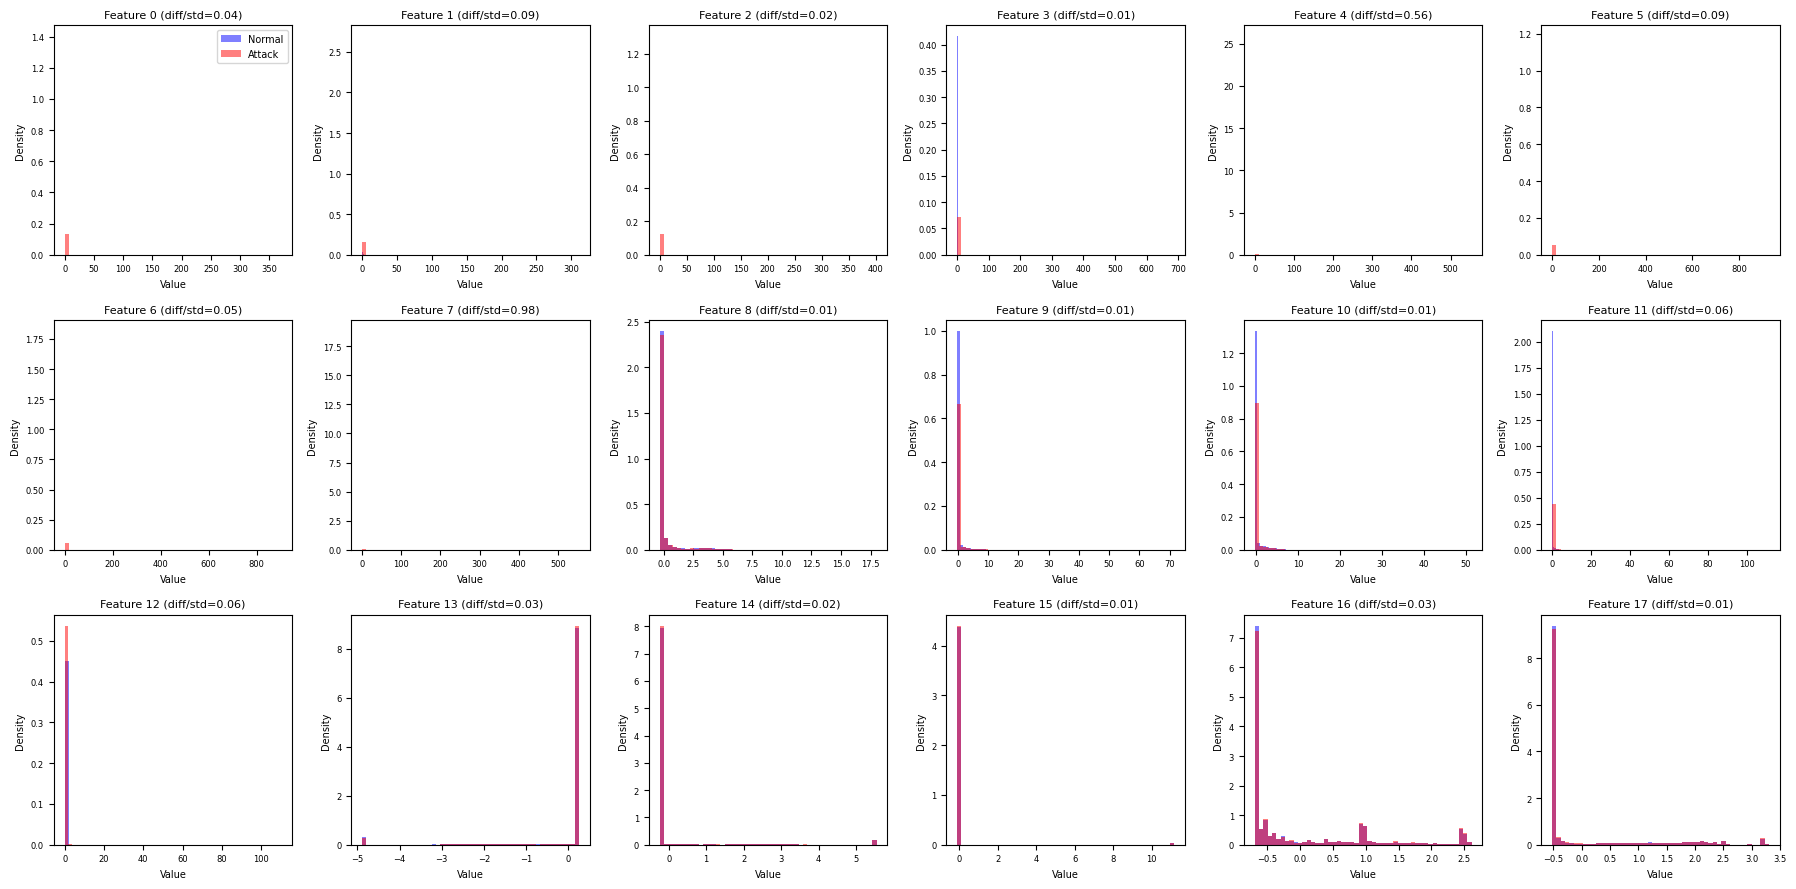


✅ Gráfico guardado: node_features_distribution.png

📊 4. OVERLAP ENTRE CLASES (PCA)


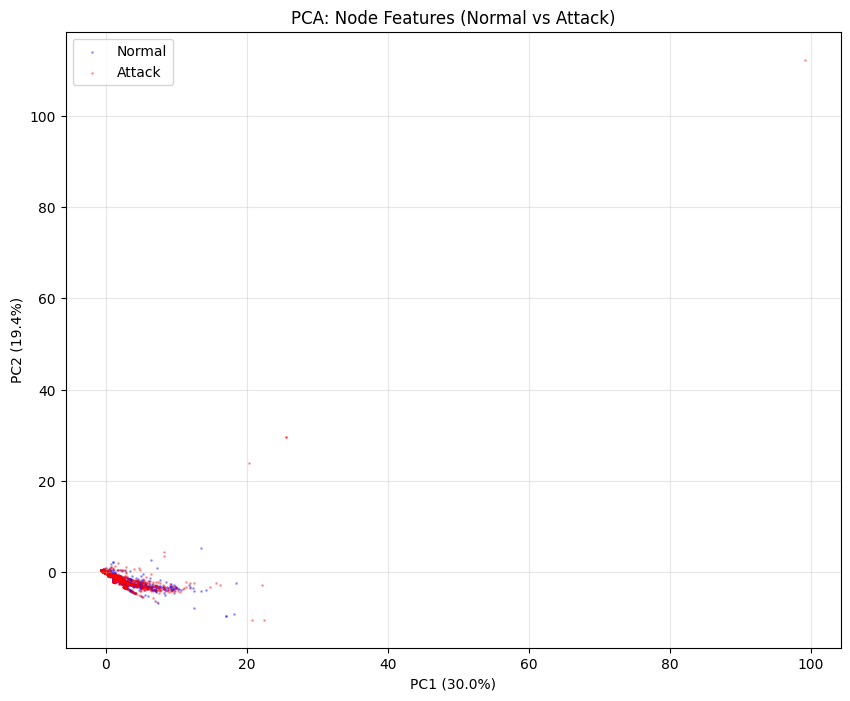


   Varianza explicada:
      PC1: 30.0%
      PC2: 19.4%
      Total (PC1+PC2): 49.4%

✅ Gráfico guardado: pca_features.png

📋 RESUMEN DEL ANÁLISIS

1. DISTRIBUCIÓN TEMPORAL:
   Train: windows 0 → 2169
   Val:   windows 1323 → 2209

2. TAMAÑO DE GRAFOS:
   Train: 2104 ± 893 nodes
   Val:   1595 ± 1190 nodes

3. SEPARABILIDAD DE FEATURES:
   ❌ MALA: Poca separación (max diff/std = 0.98 < 1.0)
      → Features muy similares entre clases
      → Problema: FEATURE ENGINEERING necesario

4. OVERLAP (PCA):
   ⚠️  MODERADO: PCA captura 49.4% varianza

5. DIAGNÓSTICO FINAL:
   ⚠️  FEATURES SON ACEPTABLES
      → Modelo puede aprender, pero con dificultad
      → Considerar feature engineering o modelo más complejo



In [ ]:
# ============================================================================
# ANÁLISIS EXPLORATORIO: Usar grafos ORIGINALES (con window_id)
# ============================================================================

print("="*70)
print("🔍 ANÁLISIS EXPLORATORIO DE DATOS")
print("="*70)

# ────────────────────────────────────────────────────────────────────
# IMPORTANTE: Usar train_graphs y val_graphs (NO los _clean)
# ────────────────────────────────────────────────────────────────────

print(f"\n📊 Datasets disponibles:")
print(f"   train_graphs:       {len(train_graphs)} grafos (originales)")
print(f"   val_graphs:         {len(val_graphs)} grafos (originales)")
print(f"   train_graphs_clean: {len(train_graphs_clean)} grafos (limpiados, sin window_id)")

# Verificar que train_graphs tiene window_id
sample = train_graphs[0]
print(f"\n🔍 Verificando grafo original:")
print(f"   Tiene window_id: {hasattr(sample, 'window_id')}")
if hasattr(sample, 'window_id'):
    print(f"   window_id ejemplo: {sample.window_id}")

# ────────────────────────────────────────────────────────────────────
# 1. DISTRIBUCIÓN TEMPORAL DE ATAQUES
# ────────────────────────────────────────────────────────────────────

print("\n📊 1. DISTRIBUCIÓN TEMPORAL")

# Usar train_graphs y val_graphs (con window_id)
train_windows = [(g.window_id, g.y.item()) for g in train_graphs]
val_windows = [(g.window_id, g.y.item()) for g in val_graphs]

train_df = pd.DataFrame(train_windows, columns=['window_id', 'label'])
val_df = pd.DataFrame(val_windows, columns=['window_id', 'label'])

print(f"\n   Train: {len(train_df)} ventanas")
print(f"      Window range: {train_df['window_id'].min()} → {train_df['window_id'].max()}")
print(f"      Normal: {sum(train_df['label']==0)}")
print(f"      Attack: {sum(train_df['label']==1)}")

print(f"\n   Val: {len(val_df)} ventanas")
print(f"      Window range: {val_df['window_id'].min()} → {val_df['window_id'].max()}")
print(f"      Normal: {sum(val_df['label']==0)}")
print(f"      Attack: {sum(val_df['label']==1)}")

# Visualizar
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Train
axes[0].scatter(train_df[train_df['label']==0]['window_id'],
                [0]*sum(train_df['label']==0),
                c='blue', alpha=0.5, label='Normal', s=10)
axes[0].scatter(train_df[train_df['label']==1]['window_id'],
                [1]*sum(train_df['label']==1),
                c='red', alpha=0.5, label='Attack', s=10)
axes[0].set_xlabel('Window ID')
axes[0].set_ylabel('Label')
axes[0].set_title('Train: Distribución Temporal de Labels')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Val
axes[1].scatter(val_df[val_df['label']==0]['window_id'],
                [0]*sum(val_df['label']==0),
                c='blue', alpha=0.5, label='Normal', s=10)
axes[1].scatter(val_df[val_df['label']==1]['window_id'],
                [1]*sum(val_df['label']==1),
                c='red', alpha=0.5, label='Attack', s=10)
axes[1].set_xlabel('Window ID')
axes[1].set_ylabel('Label')
axes[1].set_title('Val: Distribución Temporal de Labels')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('temporal_distribution.png', dpi=150)
plt.show()

print("\n✅ Gráfico guardado: temporal_distribution.png")

# ────────────────────────────────────────────────────────────────────
# 2. ESTADÍSTICAS DE GRAFOS (usar grafos originales o clean, da igual)
# ────────────────────────────────────────────────────────────────────

print("\n📊 2. ESTADÍSTICAS DE GRAFOS")

def analyze_graphs(graphs, name):
    num_nodes = [g.num_nodes for g in graphs]
    num_edges = [g.edge_index.shape[1] for g in graphs]

    labels = [g.y.item() for g in graphs]
    normal_nodes = [g.num_nodes for g in graphs if g.y.item() == 0]
    attack_nodes = [g.num_nodes for g in graphs if g.y.item() == 1]

    print(f"\n{name}:")
    print(f"   Total grafos: {len(graphs)}")
    print(f"   Num nodes - Mean: {np.mean(num_nodes):.1f}, Std: {np.std(num_nodes):.1f}, Min: {np.min(num_nodes)}, Max: {np.max(num_nodes)}")
    print(f"   Num edges - Mean: {np.mean(num_edges):.1f}, Std: {np.std(num_edges):.1f}, Min: {np.min(num_edges)}, Max: {np.max(num_edges)}")

    if len(normal_nodes) > 0:
        print(f"   Normal graphs - Avg nodes: {np.mean(normal_nodes):.1f}")
    if len(attack_nodes) > 0:
        print(f"   Attack graphs - Avg nodes: {np.mean(attack_nodes):.1f}")

    return num_nodes, num_edges, labels

# Usar grafos originales o clean (ambos tienen num_nodes, edge_index, y)
train_nodes, train_edges, train_labels = analyze_graphs(train_graphs, "TRAIN")
val_nodes, val_edges, val_labels = analyze_graphs(val_graphs, "VAL")

# Visualizar distribución de tamaños
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Helper para separar por clase
train_normal_idx = [i for i in range(len(train_graphs)) if train_labels[i]==0]
train_attack_idx = [i for i in range(len(train_graphs)) if train_labels[i]==1]
val_normal_idx = [i for i in range(len(val_graphs)) if val_labels[i]==0]
val_attack_idx = [i for i in range(len(val_graphs)) if val_labels[i]==1]

# Nodes por clase (Train)
axes[0, 0].hist([train_nodes[i] for i in train_normal_idx],
                bins=30, alpha=0.6, label='Normal', color='blue')
axes[0, 0].hist([train_nodes[i] for i in train_attack_idx],
                bins=30, alpha=0.6, label='Attack', color='red')
axes[0, 0].set_xlabel('Num Nodes')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Train: Nodes per Graph by Class')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Edges por clase (Train)
axes[0, 1].hist([train_edges[i] for i in train_normal_idx],
                bins=30, alpha=0.6, label='Normal', color='blue')
axes[0, 1].hist([train_edges[i] for i in train_attack_idx],
                bins=30, alpha=0.6, label='Attack', color='red')
axes[0, 1].set_xlabel('Num Edges')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Train: Edges per Graph by Class')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Nodes por clase (Val)
axes[1, 0].hist([val_nodes[i] for i in val_normal_idx],
                bins=30, alpha=0.6, label='Normal', color='blue')
axes[1, 0].hist([val_nodes[i] for i in val_attack_idx],
                bins=30, alpha=0.6, label='Attack', color='red')
axes[1, 0].set_xlabel('Num Nodes')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Val: Nodes per Graph by Class')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Edges por clase (Val)
axes[1, 1].hist([val_edges[i] for i in val_normal_idx],
                bins=30, alpha=0.6, label='Normal', color='blue')
axes[1, 1].hist([val_edges[i] for i in val_attack_idx],
                bins=30, alpha=0.6, label='Attack', color='red')
axes[1, 1].set_xlabel('Num Edges')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Val: Edges per Graph by Class')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('graph_size_distribution.png', dpi=150)
plt.show()

print("\n✅ Gráfico guardado: graph_size_distribution.png")

# ────────────────────────────────────────────────────────────────────
# 3. ANÁLISIS DE FEATURES (usar grafos clean o originales)
# ────────────────────────────────────────────────────────────────────

print("\n📊 3. ANÁLISIS DE NODE FEATURES")

# Extraer features de train (usar train_graphs_clean para features normalizados)
train_normal_features = []
train_attack_features = []

for g in train_graphs_clean:
    if g.y.item() == 0:
        train_normal_features.append(g.x.cpu().numpy())
    else:
        train_attack_features.append(g.x.cpu().numpy())

# Concatenar
normal_features = np.vstack(train_normal_features)  # [N_normal_nodes, 18]
attack_features = np.vstack(train_attack_features)  # [N_attack_nodes, 18]

print(f"\n   Normal nodes: {normal_features.shape[0]:,}")
print(f"   Attack nodes: {attack_features.shape[0]:,}")

# Calcular mean por feature
normal_mean = normal_features.mean(axis=0)
attack_mean = attack_features.mean(axis=0)

normal_std = normal_features.std(axis=0)
attack_std = attack_features.std(axis=0)

# Diferencia entre clases
diff = np.abs(attack_mean - normal_mean)
diff_normalized = diff / (normal_std + 1e-6)  # Normalizado por std

print(f"\n   Top 10 features más discriminativas (por diferencia/std):")
top_features = np.argsort(diff_normalized)[::-1][:10]
for i, feat_idx in enumerate(top_features):
    print(f"      {i+1}. Feature {feat_idx}: "
          f"normal_mean={normal_mean[feat_idx]:.3f}, "
          f"attack_mean={attack_mean[feat_idx]:.3f}, "
          f"diff/std={diff_normalized[feat_idx]:.3f}")

# Estadísticas generales
print(f"\n   Discriminabilidad general:")
print(f"      Max diff/std: {diff_normalized.max():.3f}")
print(f"      Mean diff/std: {diff_normalized.mean():.3f}")
print(f"      Features con diff/std > 1.0: {sum(diff_normalized > 1.0)}/18")

# Visualizar distribución de features
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
axes = axes.flatten()

for feat_idx in range(18):
    axes[feat_idx].hist(normal_features[:, feat_idx], bins=50, alpha=0.5,
                        label='Normal', color='blue', density=True)
    axes[feat_idx].hist(attack_features[:, feat_idx], bins=50, alpha=0.5,
                        label='Attack', color='red', density=True)
    axes[feat_idx].set_title(f'Feature {feat_idx} (diff/std={diff_normalized[feat_idx]:.2f})',
                             fontsize=8)
    axes[feat_idx].set_xlabel('Value', fontsize=7)
    axes[feat_idx].set_ylabel('Density', fontsize=7)
    axes[feat_idx].tick_params(labelsize=6)
    if feat_idx == 0:
        axes[feat_idx].legend(fontsize=7)

plt.tight_layout()
plt.savefig('node_features_distribution.png', dpi=150)
plt.show()

print("\n✅ Gráfico guardado: node_features_distribution.png")

# ────────────────────────────────────────────────────────────────────
# 4. PCA: Overlap entre clases
# ────────────────────────────────────────────────────────────────────

print("\n📊 4. OVERLAP ENTRE CLASES (PCA)")

from sklearn.decomposition import PCA

# Sample para PCA (demasiados puntos)
max_samples = 5000
normal_sample = normal_features[np.random.choice(len(normal_features),
                                                 min(max_samples, len(normal_features)),
                                                 replace=False)]
attack_sample = attack_features[np.random.choice(len(attack_features),
                                                 min(max_samples, len(attack_features)),
                                                 replace=False)]

all_features = np.vstack([normal_sample, attack_sample])
all_labels = np.array([0]*len(normal_sample) + [1]*len(attack_sample))

# Fit PCA
pca = PCA(n_components=2)
features_2d = pca.fit_transform(all_features)

plt.figure(figsize=(10, 8))
plt.scatter(features_2d[all_labels==0, 0], features_2d[all_labels==0, 1],
           c='blue', alpha=0.3, s=1, label='Normal')
plt.scatter(features_2d[all_labels==1, 0], features_2d[all_labels==1, 1],
           c='red', alpha=0.3, s=1, label='Attack')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA: Node Features (Normal vs Attack)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('pca_features.png', dpi=150)
plt.show()

print(f"\n   Varianza explicada:")
print(f"      PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"      PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"      Total (PC1+PC2): {sum(pca.explained_variance_ratio_)*100:.1f}%")

print("\n✅ Gráfico guardado: pca_features.png")

# ────────────────────────────────────────────────────────────────────
# RESUMEN
# ────────────────────────────────────────────────────────────────────

print("\n" + "="*70)
print("📋 RESUMEN DEL ANÁLISIS")
print("="*70)

print(f"\n1. DISTRIBUCIÓN TEMPORAL:")
print(f"   Train: windows {train_df['window_id'].min()} → {train_df['window_id'].max()}")
print(f"   Val:   windows {val_df['window_id'].min()} → {val_df['window_id'].max()}")

print(f"\n2. TAMAÑO DE GRAFOS:")
print(f"   Train: {np.mean(train_nodes):.0f} ± {np.std(train_nodes):.0f} nodes")
print(f"   Val:   {np.mean(val_nodes):.0f} ± {np.std(val_nodes):.0f} nodes")

print(f"\n3. SEPARABILIDAD DE FEATURES:")
if diff_normalized.max() > 2.0:
    print(f"   ✅ BUENA: Hay features discriminativas (max diff/std = {diff_normalized.max():.2f} > 2.0)")
    print(f"      → Features {top_features[:3].tolist()} son muy informativos")
elif diff_normalized.max() > 1.0:
    print(f"   ⚠️  MODERADA: Separación moderada (max diff/std = {diff_normalized.max():.2f} ~ 1.0-2.0)")
    print(f"      → Modelo puede aprender, pero no es fácil")
else:
    print(f"   ❌ MALA: Poca separación (max diff/std = {diff_normalized.max():.2f} < 1.0)")
    print(f"      → Features muy similares entre clases")
    print(f"      → Problema: FEATURE ENGINEERING necesario")

print(f"\n4. OVERLAP (PCA):")
total_var = sum(pca.explained_variance_ratio_)
if total_var > 0.6:
    print(f"   ✅ BUENO: PCA captura {total_var*100:.1f}% varianza (features informativos)")
elif total_var > 0.4:
    print(f"   ⚠️  MODERADO: PCA captura {total_var*100:.1f}% varianza")
else:
    print(f"   ❌ MALO: PCA captura solo {total_var*100:.1f}% varianza (features difusos)")

print(f"\n5. DIAGNÓSTICO FINAL:")
if diff_normalized.max() > 1.5 and total_var > 0.5:
    print(f"   ✅ FEATURES SON BUENOS")
    print(f"      → Problema es el MODELO o ENTRENAMIENTO")
    print(f"      → Solución: Volver a GCN simple con mejores hyperparams")
elif diff_normalized.max() > 0.8:
    print(f"   ⚠️  FEATURES SON ACEPTABLES")
    print(f"      → Modelo puede aprender, pero con dificultad")
    print(f"      → Considerar feature engineering o modelo más complejo")
else:
    print(f"   ❌ FEATURES SON INSUFICIENTES")
    print(f"      → Necesitas FEATURE ENGINEERING")
    print(f"      → O re-pensar la construcción de grafos")

print(f"\n{'='*70}")